# Data Analysis for Military Aircraft Dataset
This notebook analyzes the YOLO-OBB dataset to verify class balances, object distributions, and overall dataset health using machine learning best practices.

In [9]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm

# Set aesthetics for seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [10]:
# Setup paths
data_dir = Path("data")
yaml_path = data_dir / "data.yaml"

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
    
classes = data_config['names']
print("Loaded classes:", classes)

Loaded classes: {0: 'A1', 1: 'A2', 2: 'A3', 3: 'A4', 4: 'A5', 5: 'A6', 6: 'A7', 7: 'A8', 8: 'A9', 9: 'A10', 10: 'A11', 11: 'A12', 12: 'A13', 13: 'A14', 14: 'A15', 15: 'A16', 16: 'A17', 17: 'A18', 18: 'A19', 19: 'A20'}


## 1. Load All Annotations
We will parse every YOLO OBB label file across all splits to build a comprehensive Pandas DataFrame.

In [11]:
all_data = []

splits = ['train', 'validation', 'test']

for split in splits:
    labels_dir = data_dir / split / "labels"
    if not labels_dir.exists():
        continue
        
    for label_file in tqdm(list(labels_dir.glob("*.txt")), desc=f"Loading {split}"):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        image_id = label_file.stem
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 9: continue
            
            class_idx = int(parts[0])
            # Coordinates are normalized x1 y1 x2 y2 x3 y3 x4 y4
            pts = [float(p) for p in parts[1:9]]
            
            # Reshape into (4, 2)
            pts_array = np.array(pts, dtype=np.float32).reshape((4, 2))
            
            # Calculate Center (cx, cy)
            cx = np.mean(pts_array[:, 0])
            cy = np.mean(pts_array[:, 1])
            
            # Get minAreaRect (center_x, center_y), (width, height), angle
            # Note: the input must be in pixel space for true aspect ratio if aspect ratio of image != 1.
            # Assuming square images (800x800 for this dataset), normalized aspect ratio is the same as pixel.
            rect = cv2.minAreaRect(pts_array)
            (r_cx, r_cy), (w, h), angle = rect
            
            # Make sure w <= h to compute consistent aspect ratio
            if w > h:
                w, h = h, w
                
            area = cv2.contourArea(pts_array)
            aspect_ratio = h / w if w > 0 else 0
            
            all_data.append({
                'split': split,
                'image_id': image_id,
                'class_idx': class_idx,
                'class_name': classes.get(class_idx, str(class_idx)),
                'cx': cx,
                'cy': cy,
                'area': area,
                'aspect_ratio': aspect_ratio
            })

df = pd.DataFrame(all_data)
print(f"\nSuccessfully loaded {len(df)} annotations.")
display(df.head())

Loading test: 100%|██████████| 385/385 [00:00<00:00, 16515.20it/s]


Successfully loaded 22341 annotations.


,split,image_id,class_idx,class_name,cx,cy,area,aspect_ratio
0,train,3644,8,A9,0.520985,0.183602,0.012118,1.089649
1,train,3644,8,A9,0.470625,0.421875,0.013514,1.000000
2,train,3644,8,A9,0.449538,0.529511,0.013256,1.107857
3,train,3644,8,A9,0.438358,0.646526,0.012705,1.098720
4,train,3644,8,A9,0.401812,0.871896,0.011782,1.019185


## 2. Global Split Statistics
Let's see how the objects and images are distributed among train, validation, and test.

Total Images per split:
split
train         3073
validation     384
test           385
Name: image_id, dtype: int64


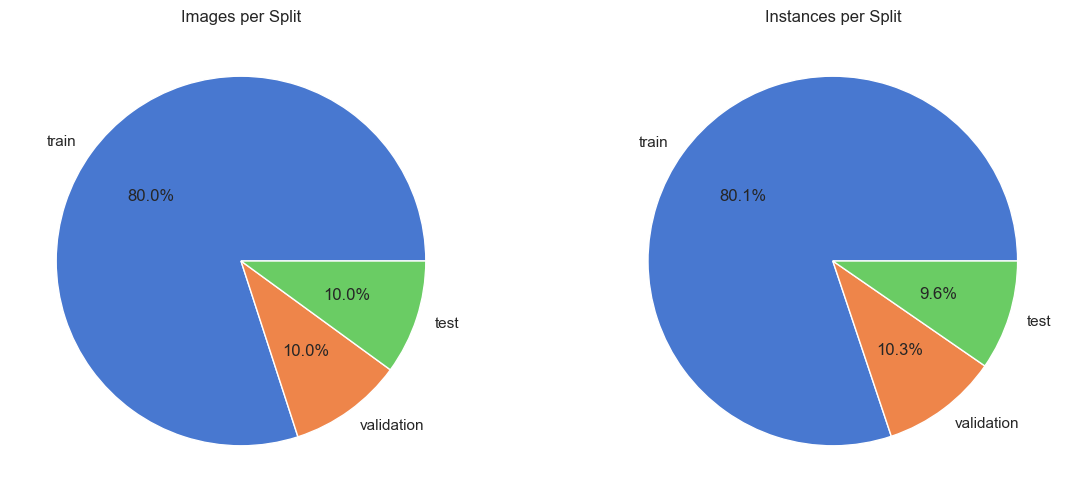

In [12]:
# Images per split
images_per_split = df.groupby('split')['image_id'].nunique().reindex(splits)
print("Total Images per split:")
print(images_per_split)

# Instances per split
instances_per_split = df['split'].value_counts().reindex(splits)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
images_per_split.plot.pie(ax=axes[0], autopct='%1.1f%%', title='Images per Split', ylabel='')
instances_per_split.plot.pie(ax=axes[1], autopct='%1.1f%%', title='Instances per Split', ylabel='')
plt.show()

## 3. Class Distribution (Checking for Imbalance)
It is crucial to know if some aircraft classes are vastly overrepresented compared to others.

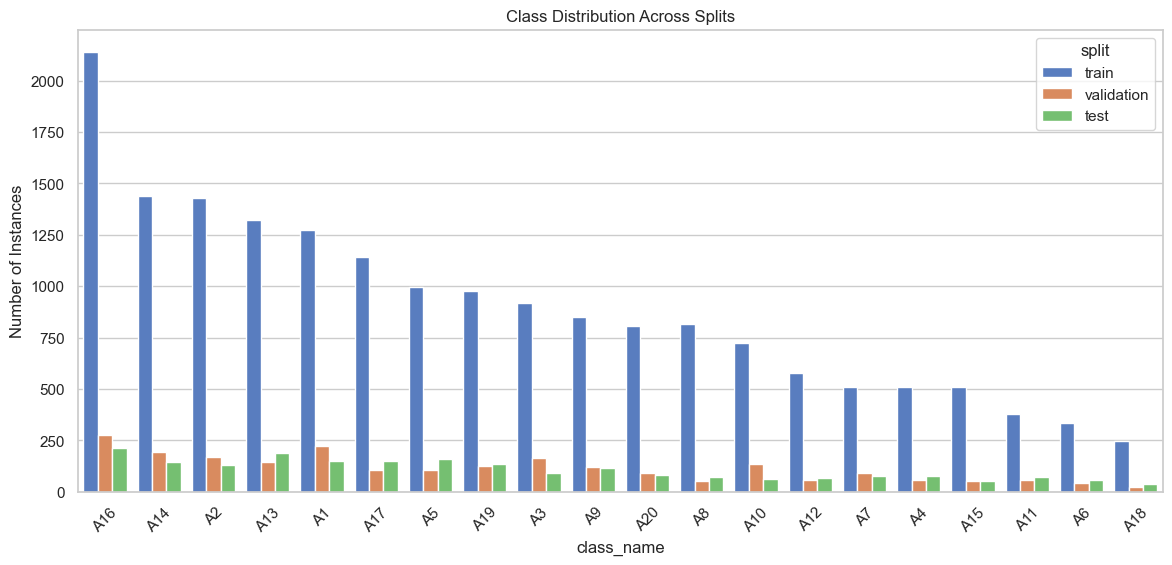

In [13]:
plt.figure(figsize=(14, 6))
order = df['class_name'].value_counts().index
sns.countplot(data=df, x='class_name', order=order, hue='split', hue_order=splits)
plt.title('Class Distribution Across Splits')
plt.xticks(rotation=45)
plt.ylabel('Number of Instances')
plt.show()

## 4. Object Density (Instances per Image)
Are the images mostly empty or heavily crowded?

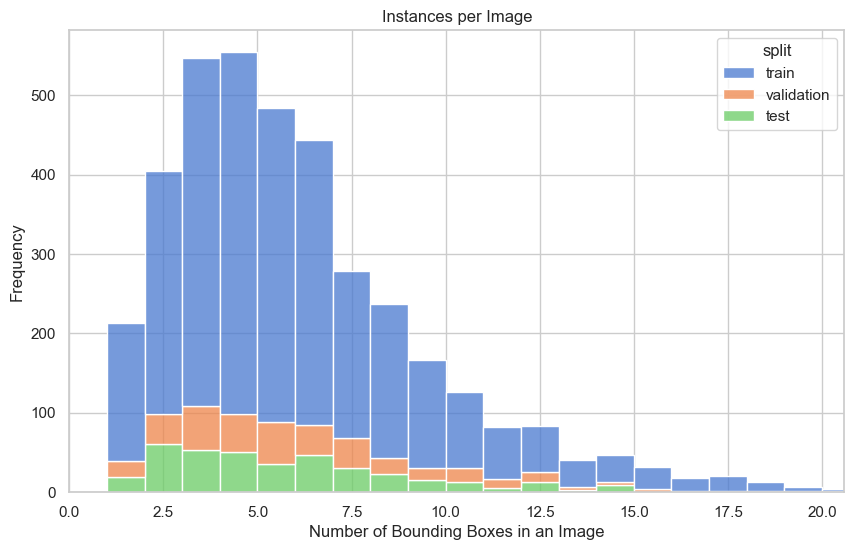

Average bounding boxes per image: 5.814940135346174
Max bounding boxes in a single image: 50


In [14]:
instances_per_image = df.groupby(['split', 'image_id']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.histplot(data=instances_per_image, x='count', hue='split', binwidth=1, multiple='stack', hue_order=splits)
plt.title('Instances per Image')
plt.xlabel('Number of Bounding Boxes in an Image')
plt.ylabel('Frequency')
plt.xlim(0, instances_per_image['count'].quantile(0.99)) # Cut off extreme outliers for better view
plt.show()

print("Average bounding boxes per image:", instances_per_image['count'].mean())
print("Max bounding boxes in a single image:", instances_per_image['count'].max())

## 5. Spatial Distribution (Location Heatmap)
Where do the targets typically appear in the frame? We can create a 2D density plot of their center coordinates. (0,0 is top-left)

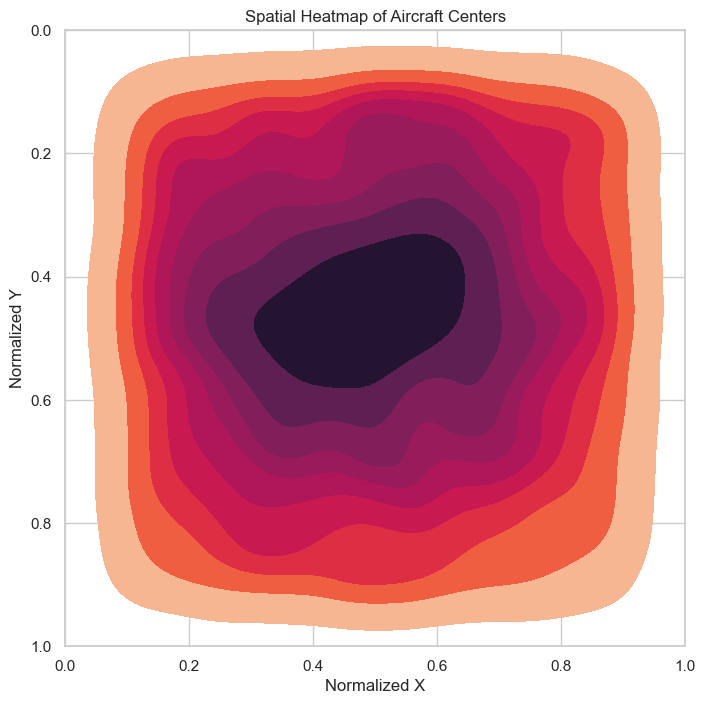

In [15]:
plt.figure(figsize=(8, 8))
# Invert y axis so it matches image coordinates (top-left is 0,0)
sns.kdeplot(x=df['cx'], y=df['cy'], cmap="rocket_r", fill=True, thresh=0.05)
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.title('Spatial Heatmap of Aircraft Centers')
plt.xlabel('Normalized X')
plt.ylabel('Normalized Y')
plt.show()

## 6. Object Size and Aspect Ratio
Understanding the physical shape of the boxes can help configure anchor boxes if needed.

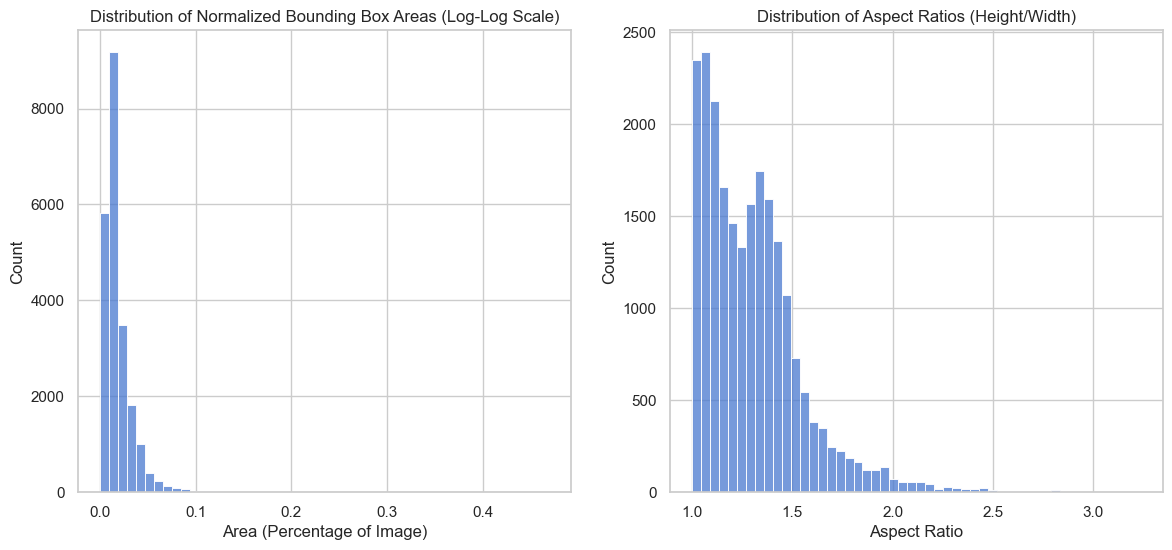

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x='area', bins=50, ax=axes[0], log_scale=(False, False))
axes[0].set_title('Distribution of Normalized Bounding Box Areas (Log-Log Scale)')
axes[0].set_xlabel('Area (Percentage of Image)')

# Filter out extreme aspect ratios caused by near 1D lines
valid_ar = df[(df['aspect_ratio'] > 1) & (df['aspect_ratio'] < 10)]
sns.histplot(data=valid_ar, x='aspect_ratio', bins=50, ax=axes[1])
axes[1].set_title('Distribution of Aspect Ratios (Height/Width)')
axes[1].set_xlabel('Aspect Ratio')

plt.show()